In [ ]:
# import os
# os.chdir('???')
# os.getcwd()
# # This work run on Google colab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
%matplotlib inline

In [ ]:
df = pd.read_csv('world_education_data_posted.csv')
df.head()

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
0,Afghanistan,Asia,1.0,32.49,11.12,0.0,56.0,54.0,23.0,104.0,9.7
1,Albania,Europe,0.0,11.78,12.33,4.0,18.0,95.0,78.0,107.0,55.0
2,Algeria,Africa,0.0,24.28,11.70,0.0,0.0,93.0,30.0,109.9,51.4
3,Andorra,Europe,0.0,7.20,0.00,0.0,0.0,0.0,0.0,106.4,0.0
4,Angola,Africa,1.0,40.73,6.89,0.0,0.0,60.0,20.0,113.5,9.3


## Check Data Size and Data Types

In [ ]:
# Check data size

In [ ]:
df.shape

(202, 11)

In [ ]:
# Check data types

In [ ]:
df.dtypes

Countries and areas                     object
Continent                               object
ThirdWorld                             float64
Birth_Rate                             float64
Unemployment_Rate                      float64
OOS_Primary_Age                        float64
OOS_HighSchool_Age                     float64
Completion_Primary_Age                 float64
Completion_HighSchool_Age              float64
Gross_Primary_Education_Enrollment     float64
Gross_Tertiary_Education_Enrollment    float64
dtype: object

In [ ]:
# Check attributes (columns)

In [ ]:
df.columns

Index(['Countries and areas', 'Continent', 'ThirdWorld', 'Birth_Rate',
       'Unemployment_Rate', 'OOS_Primary_Age', 'OOS_HighSchool_Age',
       'Completion_Primary_Age', 'Completion_HighSchool_Age',
       'Gross_Primary_Education_Enrollment',
       'Gross_Tertiary_Education_Enrollment'],
      dtype='object')

## Handle Missing Data

In [ ]:
# Show heatmap with missing data

In [ ]:
df.isnull()

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
197,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False
199,False,False,False,False,False,False,False,False,False,False,False
200,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

Countries and areas                     1
Continent                              10
ThirdWorld                             12
Birth_Rate                              0
Unemployment_Rate                       0
OOS_Primary_Age                         0
OOS_HighSchool_Age                      0
Completion_Primary_Age                  0
Completion_HighSchool_Age               0
Gross_Primary_Education_Enrollment      0
Gross_Tertiary_Education_Enrollment     0
dtype: int64

<Axes: >

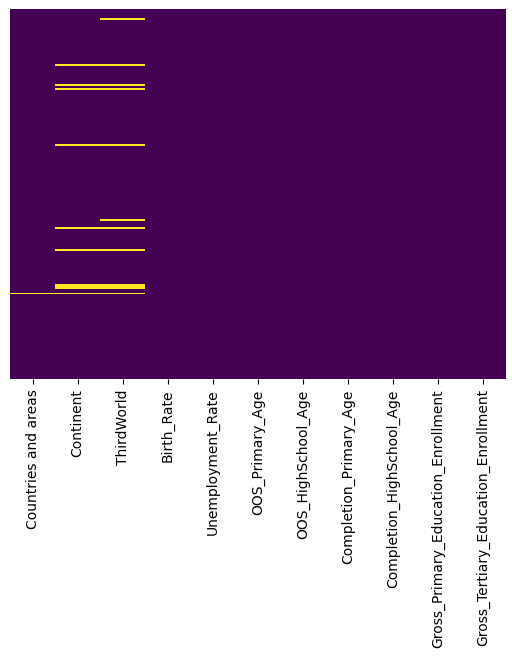

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [ ]:
# find which column has missing data percent > 0

In [ ]:
null_percent = df.isnull().sum()/len(df)*100
null_percent

Countries and areas                    0.495050
Continent                              4.950495
ThirdWorld                             5.940594
Birth_Rate                             0.000000
Unemployment_Rate                      0.000000
OOS_Primary_Age                        0.000000
OOS_HighSchool_Age                     0.000000
Completion_Primary_Age                 0.000000
Completion_HighSchool_Age              0.000000
Gross_Primary_Education_Enrollment     0.000000
Gross_Tertiary_Education_Enrollment    0.000000
dtype: float64

In [ ]:
null_percent = df.isnull().sum()/len(df)*100
missing_data_more_zero = null_percent[null_percent > 0]
missing_data_more_zero

Countries and areas    0.495050
Continent              4.950495
ThirdWorld             5.940594
dtype: float64

In [ ]:
# If we replace missing continent with one value, what will it be ?
# Show your work below

In [ ]:
replace_no_assign = pd.read_csv('world_education_data_posted.csv')
replace_no_assign['Continent'] = df['Continent'].fillna('Continent N/A')
replace_no_assign['Countries and areas'] = df['Countries and areas'].fillna('Area N/A')
replace_no_assign['ThirdWorld'] = df['ThirdWorld'].fillna(3)
replace_no_assign

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
0,Afghanistan,Asia,1.0,32.49,11.12,0.0,56.0,54.0,23.0,104.0,9.7
1,Albania,Europe,0.0,11.78,12.33,4.0,18.0,95.0,78.0,107.0,55.0
2,Algeria,Africa,0.0,24.28,11.70,0.0,0.0,93.0,30.0,109.9,51.4
3,Andorra,Europe,0.0,7.20,0.00,0.0,0.0,0.0,0.0,106.4,0.0
4,Angola,Africa,1.0,40.73,6.89,0.0,0.0,60.0,20.0,113.5,9.3
...,...,...,...,...,...,...,...,...,...,...,...
197,Venezuela,South America,0.0,17.88,8.80,10.0,24.0,0.0,0.0,97.2,79.3
198,Vietnam,Asia,0.0,16.75,2.01,0.0,0.0,96.0,56.0,110.6,28.5
199,Yemen,Africa,0.0,30.45,12.91,16.0,57.0,62.0,30.0,93.6,10.2
200,Zambia,Africa,1.0,36.19,11.43,15.0,0.0,72.0,30.0,98.7,4.1


In [ ]:
# In this data set, should you replace the missing continent with the selected value above ?
# Why or why not?
# Answer : **** No, because we are not know what exactly value??? Data will be can used because the wrong information. ****

In [ ]:
# Replace or Drop the missing data

In [ ]:
df_clean = df.dropna()

In [ ]:
df

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
0,Afghanistan,Asia,1.0,32.49,11.12,0.0,56.0,54.0,23.0,104.0,9.7
1,Albania,Europe,0.0,11.78,12.33,4.0,18.0,95.0,78.0,107.0,55.0
2,Algeria,Africa,0.0,24.28,11.70,0.0,0.0,93.0,30.0,109.9,51.4
3,Andorra,Europe,0.0,7.20,0.00,0.0,0.0,0.0,0.0,106.4,0.0
4,Angola,Africa,1.0,40.73,6.89,0.0,0.0,60.0,20.0,113.5,9.3
...,...,...,...,...,...,...,...,...,...,...,...
197,Venezuela,South America,0.0,17.88,8.80,10.0,24.0,0.0,0.0,97.2,79.3
198,Vietnam,Asia,0.0,16.75,2.01,0.0,0.0,96.0,56.0,110.6,28.5
199,Yemen,Africa,0.0,30.45,12.91,16.0,57.0,62.0,30.0,93.6,10.2
200,Zambia,Africa,1.0,36.19,11.43,15.0,0.0,72.0,30.0,98.7,4.1


In [ ]:
df_clean

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
0,Afghanistan,Asia,1.0,32.49,11.12,0.0,56.0,54.0,23.0,104.0,9.7
1,Albania,Europe,0.0,11.78,12.33,4.0,18.0,95.0,78.0,107.0,55.0
2,Algeria,Africa,0.0,24.28,11.70,0.0,0.0,93.0,30.0,109.9,51.4
3,Andorra,Europe,0.0,7.20,0.00,0.0,0.0,0.0,0.0,106.4,0.0
4,Angola,Africa,1.0,40.73,6.89,0.0,0.0,60.0,20.0,113.5,9.3
...,...,...,...,...,...,...,...,...,...,...,...
197,Venezuela,South America,0.0,17.88,8.80,10.0,24.0,0.0,0.0,97.2,79.3
198,Vietnam,Asia,0.0,16.75,2.01,0.0,0.0,96.0,56.0,110.6,28.5
199,Yemen,Africa,0.0,30.45,12.91,16.0,57.0,62.0,30.0,93.6,10.2
200,Zambia,Africa,1.0,36.19,11.43,15.0,0.0,72.0,30.0,98.7,4.1


In [ ]:
# Check out the updated data size

In [ ]:
df.shape # Before Clean

(202, 11)

In [ ]:
df_clean.shape

(190, 11)

## Data Distributions / Histograms

In [ ]:
# Show data row belongs to Thailand

In [ ]:
belongs_to_thailand = df_clean[df_clean['Countries and areas'] == 'Thailand']
belongs_to_thailand

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
177,Thailand,Asia,0.0,10.34,0.75,0.0,21.0,98.0,66.0,99.8,49.3


In [ ]:
# Show data column for Countries and areas

In [ ]:
countries_area_show = df_clean['Countries and areas']
countries_area_show

0      Afghanistan
1          Albania
2          Algeria
3          Andorra
4           Angola
          ...     
197      Venezuela
198        Vietnam
199          Yemen
200         Zambia
201       Zimbabwe
Name: Countries and areas, Length: 190, dtype: object

In [ ]:
# Plot histograms for all numerical data in 1 command

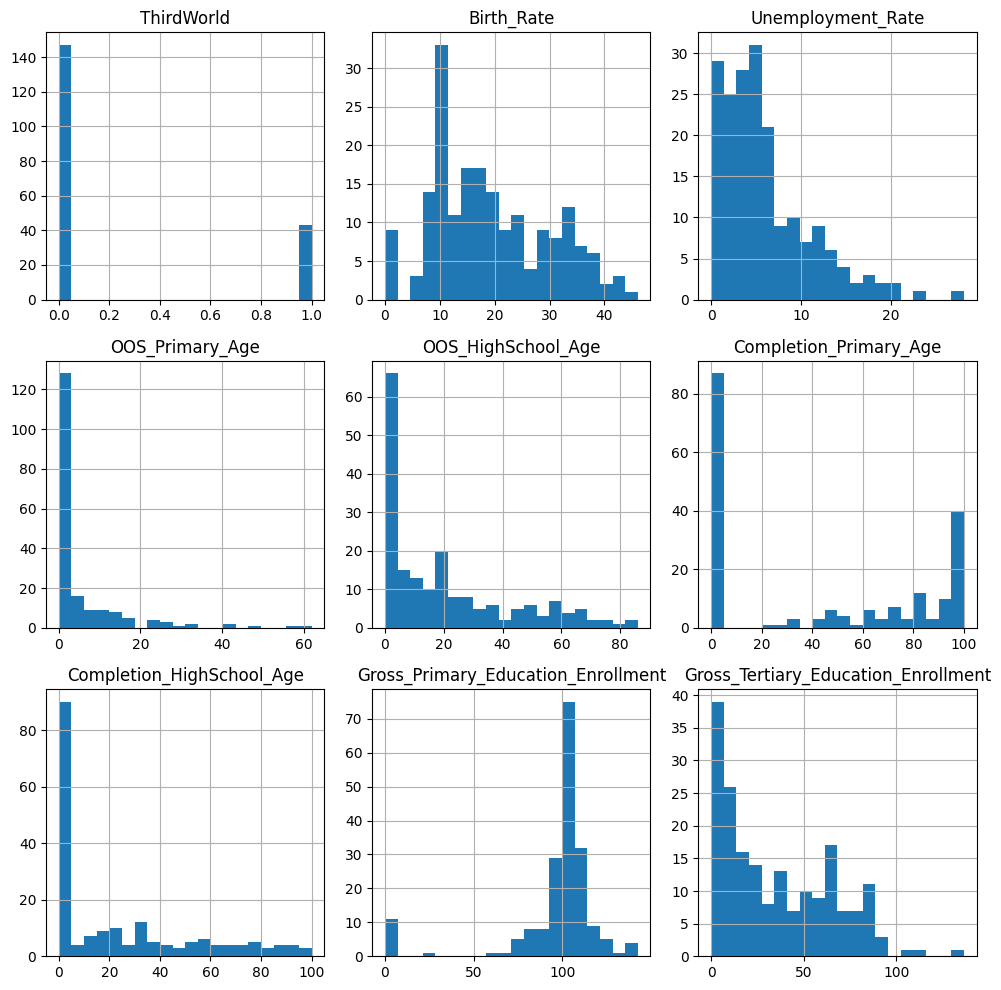

In [ ]:
df_clean.hist(figsize=(10, 10), bins=20)
plt.tight_layout()
plt.show()

In [ ]:
# Plot histograms for Gross_Primary_Education_Enrollment

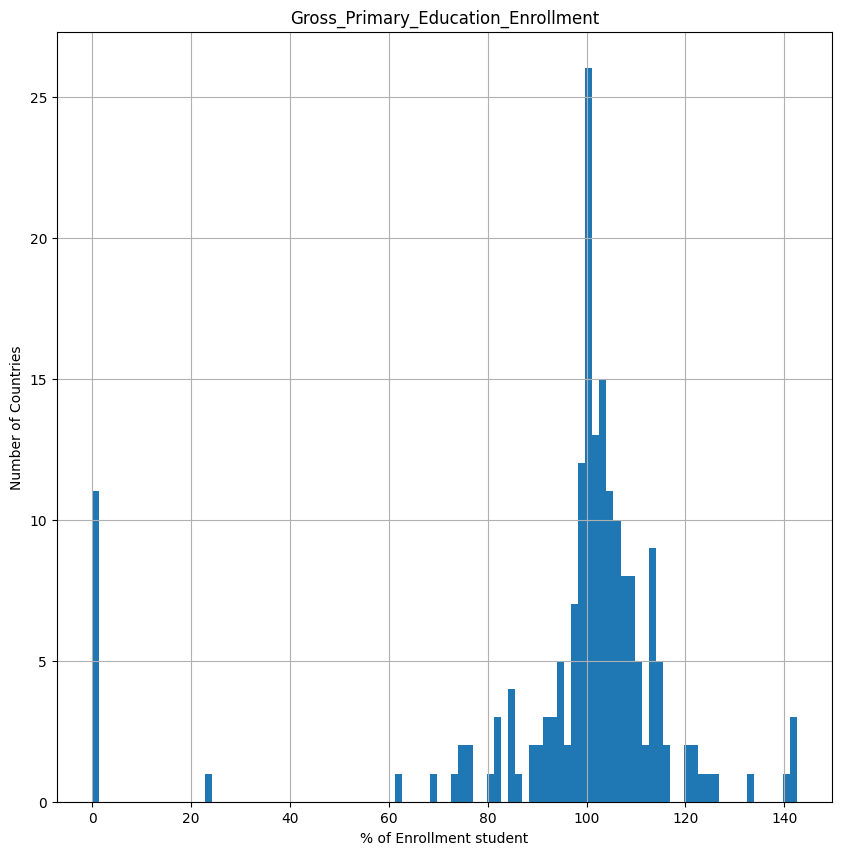

In [ ]:
df_clean['Gross_Primary_Education_Enrollment'].hist(figsize=(10, 10), bins=100)
plt.title('Gross_Primary_Education_Enrollment')
plt.ylabel('Number of Countries')
plt.xlabel('% of Enrollment student')
plt.show()

In [ ]:
# Plot histograms for Gross_Tertiary_Education_Enrollment

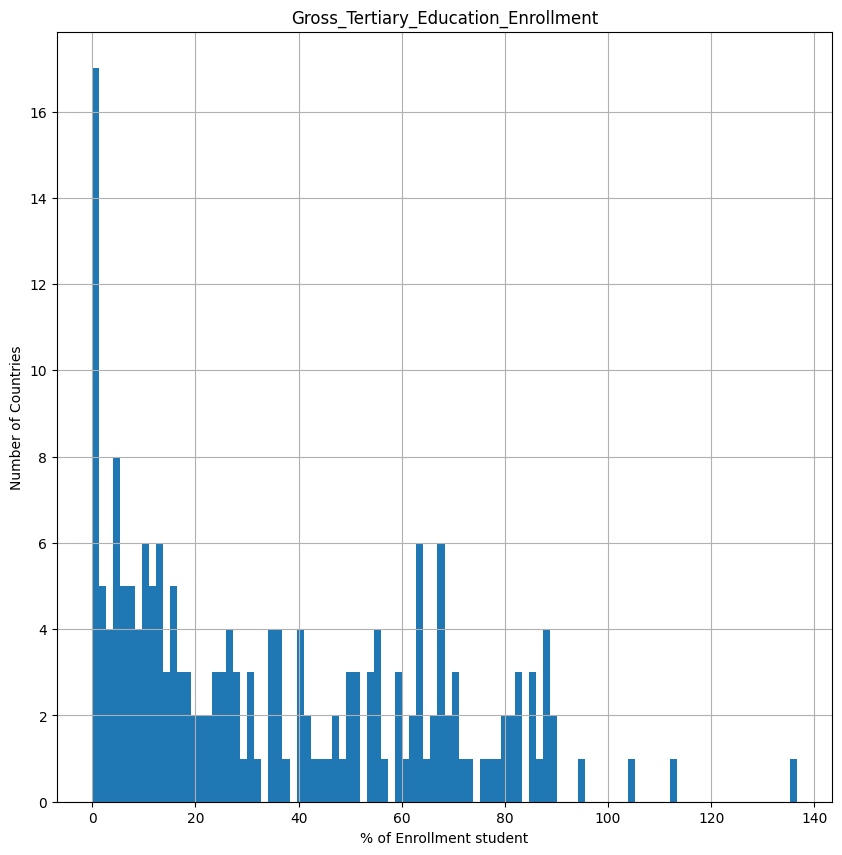

In [ ]:
df_clean['Gross_Tertiary_Education_Enrollment'].hist(figsize=(10, 10), bins=100)
plt.title('Gross_Tertiary_Education_Enrollment')
plt.ylabel('Number of Countries')
plt.xlabel('% of Enrollment student')
plt.show()

In [ ]:
# Compare enrollment percents between primary and tertiary educations
# Answer: There's clearly that the data from primary is higher than teriary education. Highly amount of countries is lower than 20%. Opposite to the primary that has almost of country in the range of 80-120%

In [ ]:
# How Thailand stands for enrollment percents of primary and tertiary educations, compared to other countries?
# Answer: Thai Primary_Education_Enrollment enrollment stand in median at 99.8%. But for Tertiary_Education_Enrollment are lower when comparison with Primary by acoording to the trend of data at 49.3%.

In [ ]:
# Plot overlay histogram for OOS_Primary_Age (red) and Completion_Primary_Age (green)
# Label title, x and y axes accordingly

Text(0.5, 0, 'AGE')

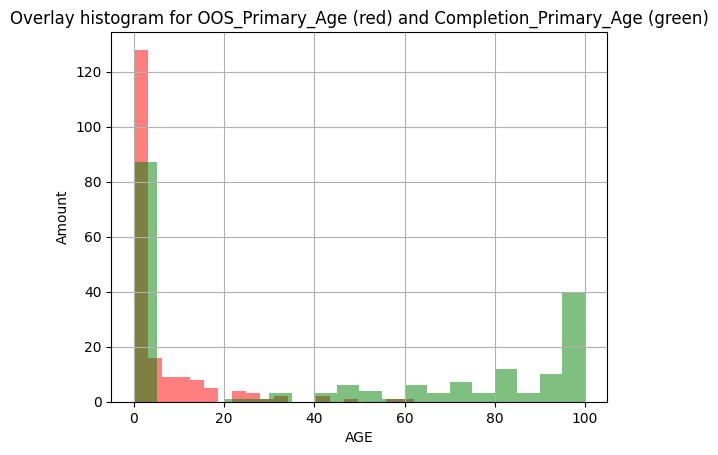

In [ ]:
df_clean['OOS_Primary_Age'].hist(alpha=0.5, color='red', bins=20, label='OOS Primary Age')
df_clean['Completion_Primary_Age'].hist(alpha=0.5, color='green', bins=20, label='Completion Primary Age')
plt.title('Overlay histogram for OOS_Primary_Age (red) and Completion_Primary_Age (green)')
plt.ylabel('Amount')
plt.xlabel('AGE')

In [ ]:
# Plot overlay histogram for OOS_Primary_Age (red) and OOS_HighSchool_Age (orange)
# Label title, x and y axes accordingly

Text(0.5, 0, 'AGE')

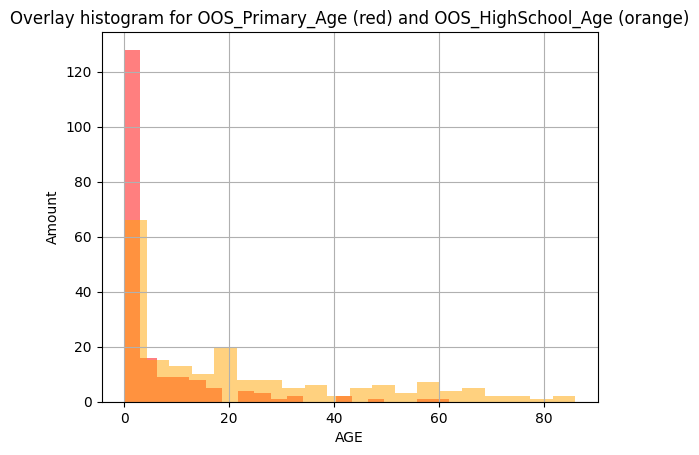

In [ ]:
df_clean['OOS_Primary_Age'].hist(alpha=0.5, color='red', bins=20, label='OOS Primary Age')
df_clean['OOS_HighSchool_Age'].hist(alpha=0.5, color='orange', bins=20, label='OOS_HighSchool_Age')
plt.title('Overlay histogram for OOS_Primary_Age (red) and OOS_HighSchool_Age (orange)')
plt.ylabel('Amount')
plt.xlabel('AGE')

In [ ]:
# Summarize what you learn from two overlay histograms above
# Answer: Out-of-school rate for primary age and Out-of-school rate for high school age are trending in the same way.
#         Also with Out-of-school rate for primary age and Completion rate for primary education also trending in same way.

## Data Distributions / Boxplots

In [ ]:
# Find out unique continents

In [ ]:
unique_continents = df_clean['Continent'].unique()
unique_continents

array(['Asia', 'Europe', 'Africa', 'North America', 'South America',
       'Australia'], dtype=object)

In [ ]:
# Plot botplot for Completion_Primary_Age for different continents

Text(0.5, 1.0, 'Botplot for Completion_Primary_Age for different continents')

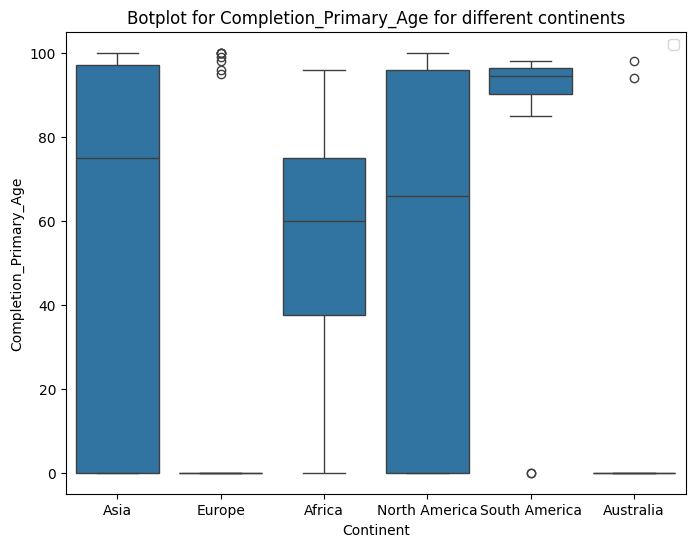

In [ ]:
fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Continent', y='Completion_Primary_Age', data=df_clean,)
plt.legend(loc='upper right')
plt.title('Botplot for Completion_Primary_Age for different continents')


In [ ]:
# Plot botplot for Completion_HighSchool_Age for different continents

Text(0.5, 1.0, 'Botplot for Completion_HighSchool_Age for different continents')

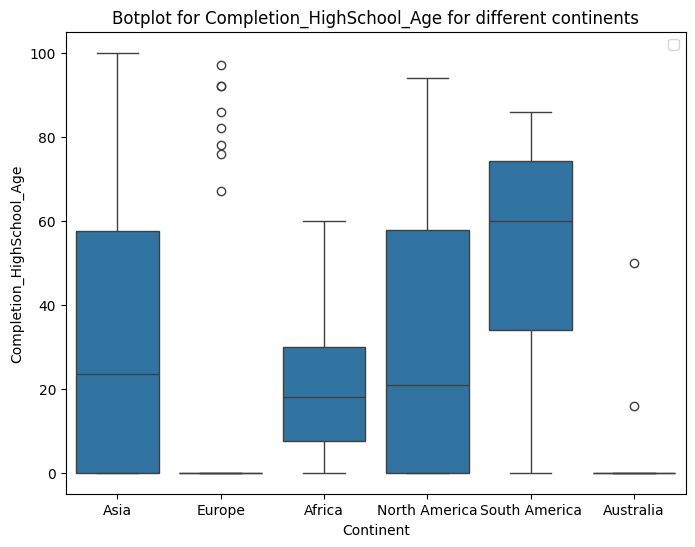

In [ ]:
fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Continent', y='Completion_HighSchool_Age', data=df_clean,)
plt.legend(loc='upper right')
plt.title('Botplot for Completion_HighSchool_Age for different continents')

In [ ]:
# Look at Europe and Australia boxplots, try to figure out why the boxplots appear like that
# List values from continent Europe and from columne Completion_HighSchool_Age

In [ ]:
europe_completion_highSchool_age = df_clean.loc[df_clean['Continent'] == 'Europe', 'Completion_HighSchool_Age']
europe_completion_highSchool_age

1      78.0
3       0.0
10      0.0
16     92.0
17      0.0
22     92.0
27      0.0
44      0.0
47      0.0
50      0.0
59      0.0
63      0.0
64      0.0
68      0.0
70      0.0
77      0.0
79      0.0
80      0.0
85      0.0
87      0.0
97      0.0
102     0.0
103     0.0
104     0.0
110     0.0
116     0.0
118    86.0
126     0.0
132    82.0
133     0.0
142     0.0
143     0.0
146    67.0
147     0.0
154     0.0
158    76.0
162     0.0
163     0.0
168     0.0
173     0.0
174     0.0
189    97.0
191     0.0
Name: Completion_HighSchool_Age, dtype: float64

In [ ]:
# List values from continent Australia and from columne Completion_HighSchool_Age

In [ ]:
europe_completion_highSchool_age = df_clean.loc[df_clean['Continent'] == 'Australia', 'Completion_HighSchool_Age']
europe_completion_highSchool_age

9       0.0
62      0.0
93     16.0
111     0.0
124     0.0
127     0.0
136     0.0
138     0.0
153     0.0
164     0.0
180     0.0
181    50.0
187     0.0
196     0.0
Name: Completion_HighSchool_Age, dtype: float64

In [ ]:
# Do the values from both Europe and Australia seem to be sensible ? ### Answer is No.
# If not, drop the data with both continents from the dataframe
# REMINDER : Name this resulting dataframe with the NEW ONE
# HINT: function index and convert to list may be helpful.

In [ ]:
Q1_AU = df_clean[(df_clean['Continent'] == 'Australia')]['Completion_HighSchool_Age'].quantile(0.25)
Q3_AU = df_clean[(df_clean['Continent'] == 'Australia')]['Completion_HighSchool_Age'].quantile(0.75)
IQR_AU = Q3_AU - Q1_AU
lower_bound_AU = Q1_AU - 1.5 * IQR_AU
upper_bound_AU = Q3_AU + 1.5 * IQR_AU
print(f"Q1_AU is {Q1_AU} : Q1_AU is {Q3_AU} : IQR_AU is {IQR_AU} : lower_bound_AU is {lower_bound_AU} : upper_bound_AU is {upper_bound_AU}")

Q1_AU is 0.0 : Q1_AU is 0.0 : IQR_AU is 0.0 : lower_bound_AU is 0.0 : upper_bound_AU is 0.0


In [ ]:
df_clean2_au = df_clean[df_clean['Continent'] != 'Australia']
df_clean2_europe_and_au = df_clean2_au[df_clean2_au['Continent'] != 'Europe']

In [ ]:
# Check out the new size of the new data frame after dropping Europe and Australia

In [ ]:
df_clean2_europe_and_au

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
0,Afghanistan,Asia,1.0,32.49,11.12,0.0,56.0,54.0,23.0,104.0,9.7
2,Algeria,Africa,0.0,24.28,11.70,0.0,0.0,93.0,30.0,109.9,51.4
4,Angola,Africa,1.0,40.73,6.89,0.0,0.0,60.0,20.0,113.5,9.3
6,Antigua and Barbuda,North America,0.0,15.33,0.00,2.0,13.0,0.0,0.0,105.0,24.8
7,Argentina,South America,0.0,17.02,9.79,0.0,11.0,92.0,50.0,109.7,90.0
...,...,...,...,...,...,...,...,...,...,...,...
197,Venezuela,South America,0.0,17.88,8.80,10.0,24.0,0.0,0.0,97.2,79.3
198,Vietnam,Asia,0.0,16.75,2.01,0.0,0.0,96.0,56.0,110.6,28.5
199,Yemen,Africa,0.0,30.45,12.91,16.0,57.0,62.0,30.0,93.6,10.2
200,Zambia,Africa,1.0,36.19,11.43,15.0,0.0,72.0,30.0,98.7,4.1


In [ ]:
# Replot boxplot for Completion_HighSchool_Age for different continents (now without Europe and Australia)

Text(0.5, 1.0, 'Botplot for Completion_HighSchool_Age for different continents after dropping Europe and Australia')

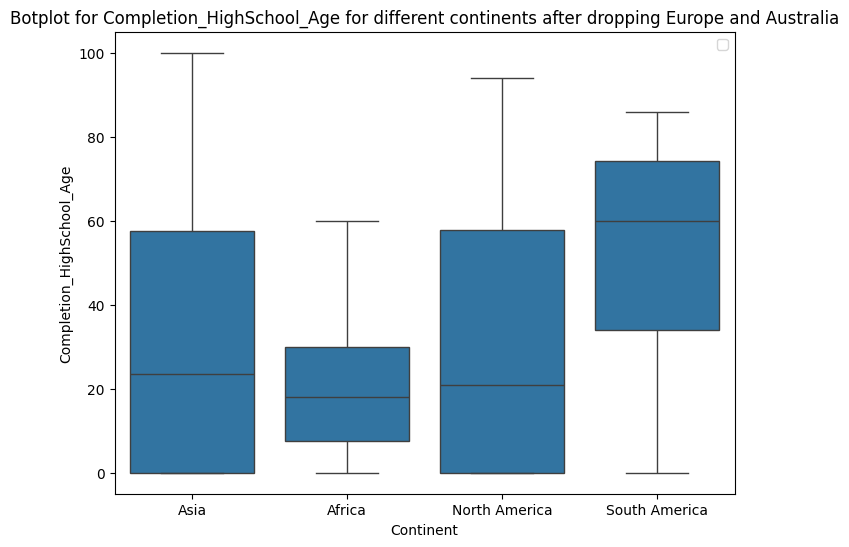

In [ ]:
fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Continent', y='Completion_HighSchool_Age', data=df_clean2_europe_and_au,)
plt.legend(loc='upper right')
plt.title('Botplot for Completion_HighSchool_Age for different continents after dropping Europe and Australia')

In [ ]:
# Plot boxplot for OOS_Primary_Age for different continents and use hue for ThirdWorld values

Text(0.5, 1.0, 'Botplot for OOS_Primary_Age for different continents after dropping Europe and Australia')

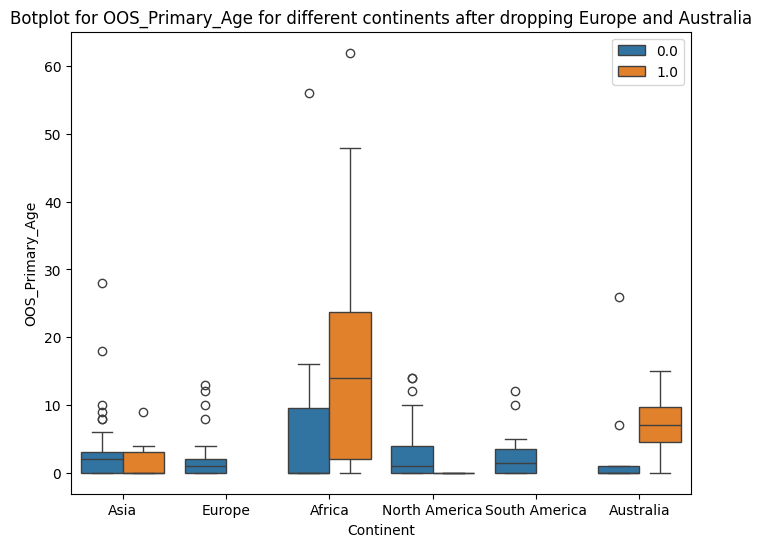

In [ ]:
fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Continent', y='OOS_Primary_Age', data=df_clean, hue='ThirdWorld')
plt.legend(loc='upper right')
plt.title('Botplot for OOS_Primary_Age for different continents after dropping Europe and Australia')

In [ ]:
# Since values of 0, 1 for ThirdWorld are not self-explained,
# Replace 0 with 'Not Third World', and 1 with 'Third World' in the ORIGINAL dataframe
# Hint: function where from numpy may be useful here.

In [ ]:
df_clean_third_world = df_clean.copy()
#df_clean_numpy['ThirdWorld'] = np.where(df_clean_numpy['ThirdWorld'] == 0, 'Not Third World', 'Third World')
df_clean_third_world['ThirdWorld'].replace(0, 'Not Third World', inplace=True)
df_clean_third_world['ThirdWorld'].replace(1, 'Third World', inplace=True)


In [ ]:
# Replot boxplot for OOS_Primary_Age for different continents and use hue for new ThirdWorld values
# Now legend for ThirdWorld should show values: 'Not Third World', 'Third World', instead of 0 and 1.

In [ ]:
df_clean_third_world

,Countries and areas,Continent,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
0,Afghanistan,Asia,Third World,32.49,11.12,0.0,56.0,54.0,23.0,104.0,9.7
1,Albania,Europe,Not Third World,11.78,12.33,4.0,18.0,95.0,78.0,107.0,55.0
2,Algeria,Africa,Not Third World,24.28,11.70,0.0,0.0,93.0,30.0,109.9,51.4
3,Andorra,Europe,Not Third World,7.20,0.00,0.0,0.0,0.0,0.0,106.4,0.0
4,Angola,Africa,Third World,40.73,6.89,0.0,0.0,60.0,20.0,113.5,9.3
...,...,...,...,...,...,...,...,...,...,...,...
197,Venezuela,South America,Not Third World,17.88,8.80,10.0,24.0,0.0,0.0,97.2,79.3
198,Vietnam,Asia,Not Third World,16.75,2.01,0.0,0.0,96.0,56.0,110.6,28.5
199,Yemen,Africa,Not Third World,30.45,12.91,16.0,57.0,62.0,30.0,93.6,10.2
200,Zambia,Africa,Third World,36.19,11.43,15.0,0.0,72.0,30.0,98.7,4.1


Text(0.5, 1.0, 'Botplot for OOS_Primary_Age for different continents after replaced not numpy')

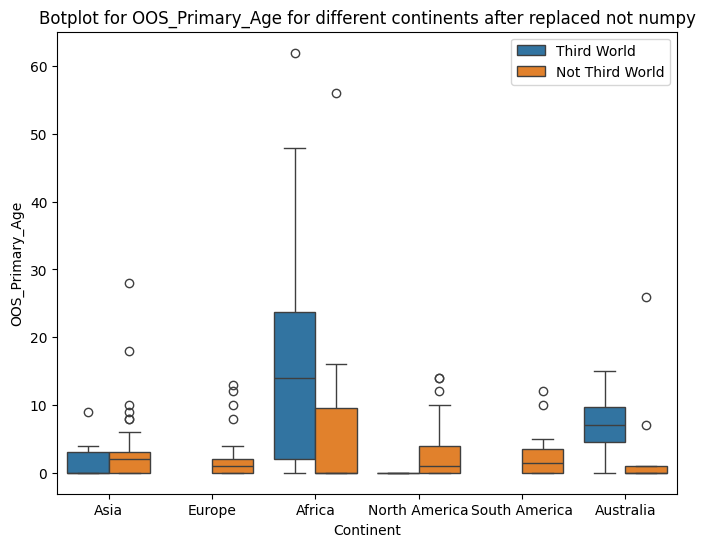

In [ ]:
fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Continent', y='OOS_Primary_Age', data=df_clean_third_world, hue='ThirdWorld')
plt.legend(loc='upper right')
plt.title('Botplot for OOS_Primary_Age for different continents after replaced not numpy')

In [ ]:
# Plot boxplot for OOS_HighSchool_Age for different continents and use hue for new ThirdWorld values

Text(0.5, 1.0, 'Botplot for OOS_Primary_Age for different continents after replaced not numpy')

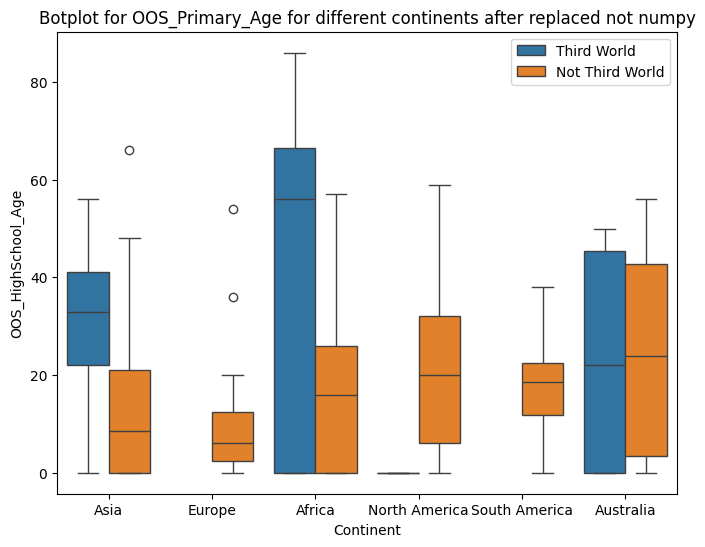

In [ ]:
fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Continent', y='OOS_HighSchool_Age', data=df_clean_third_world, hue='ThirdWorld')
plt.legend(loc='upper right')
plt.title('Botplot for OOS_Primary_Age for different continents after replaced not numpy')

## Descriptive Statistics

In [ ]:
# Show the descriptive statistics comparison before and after Europe and Australia are dropped
# Show your work below

In [ ]:
print("Before Europe and Australia dropped")
df_clean.describe()

Before Europe and Australia dropped


,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
count,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,0.226316,19.142474,6.005263,5.494737,20.542105,43.189474,23.731579,96.458947,35.577895
std,0.419551,10.614878,5.080148,10.079970,22.348983,42.685709,29.613320,27.239030,29.970653
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,10.415000,2.460000,0.000000,2.000000,0.000000,0.000000,97.350000,9.400000
50%,0.000000,17.555000,4.590000,2.000000,13.000000,45.000000,10.000000,101.850000,27.400000
75%,0.000000,27.692500,8.415000,6.000000,32.750000,92.000000,41.750000,107.300000,61.400000
max,1.000000,46.080000,28.180000,62.000000,86.000000,100.000000,100.000000,142.500000,136.600000


In [ ]:
print("After Europe and Australia dropped")
df_clean2_europe_and_au.describe()

After Europe and Australia dropped


,ThirdWorld,Birth_Rate,Unemployment_Rate,OOS_Primary_Age,OOS_HighSchool_Age,Completion_Primary_Age,Completion_HighSchool_Age,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment
count,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,0.293233,22.450977,6.487895,6.744361,23.781955,54.330827,28.368421,99.330075,28.862406
std,0.456966,10.129462,5.293642,11.432711,24.043628,39.896024,28.358226,23.032010,25.318072
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,14.900000,2.640000,0.000000,0.000000,0.000000,0.000000,97.100000,9.000000
50%,0.000000,20.550000,4.950000,2.000000,18.000000,66.000000,22.000000,102.600000,20.600000
75%,1.000000,31.610000,9.470000,9.000000,38.000000,93.000000,48.000000,108.800000,44.900000
max,1.000000,46.080000,28.180000,62.000000,86.000000,100.000000,100.000000,142.500000,104.600000


In [ ]:
# Are there any outliers for OOS_HighSchool_Age of Asia ## 24.25 + 1.5*24.25 = 60.625 -> มีหลุด? max 66 ????
# Show your work below

In [ ]:
outlier_asia = df_clean[df_clean['Continent'] == 'Asia']['OOS_HighSchool_Age'].describe()
outlier_asia

count    48.000000
mean     15.750000
std      17.248497
min       0.000000
25%       0.000000
50%      12.000000
75%      24.250000
max      66.000000
Name: OOS_HighSchool_Age, dtype: float64

## Scatter Plots and Correlation

In [ ]:
# Show scatterplot matrix for numerical columns from original dataframe

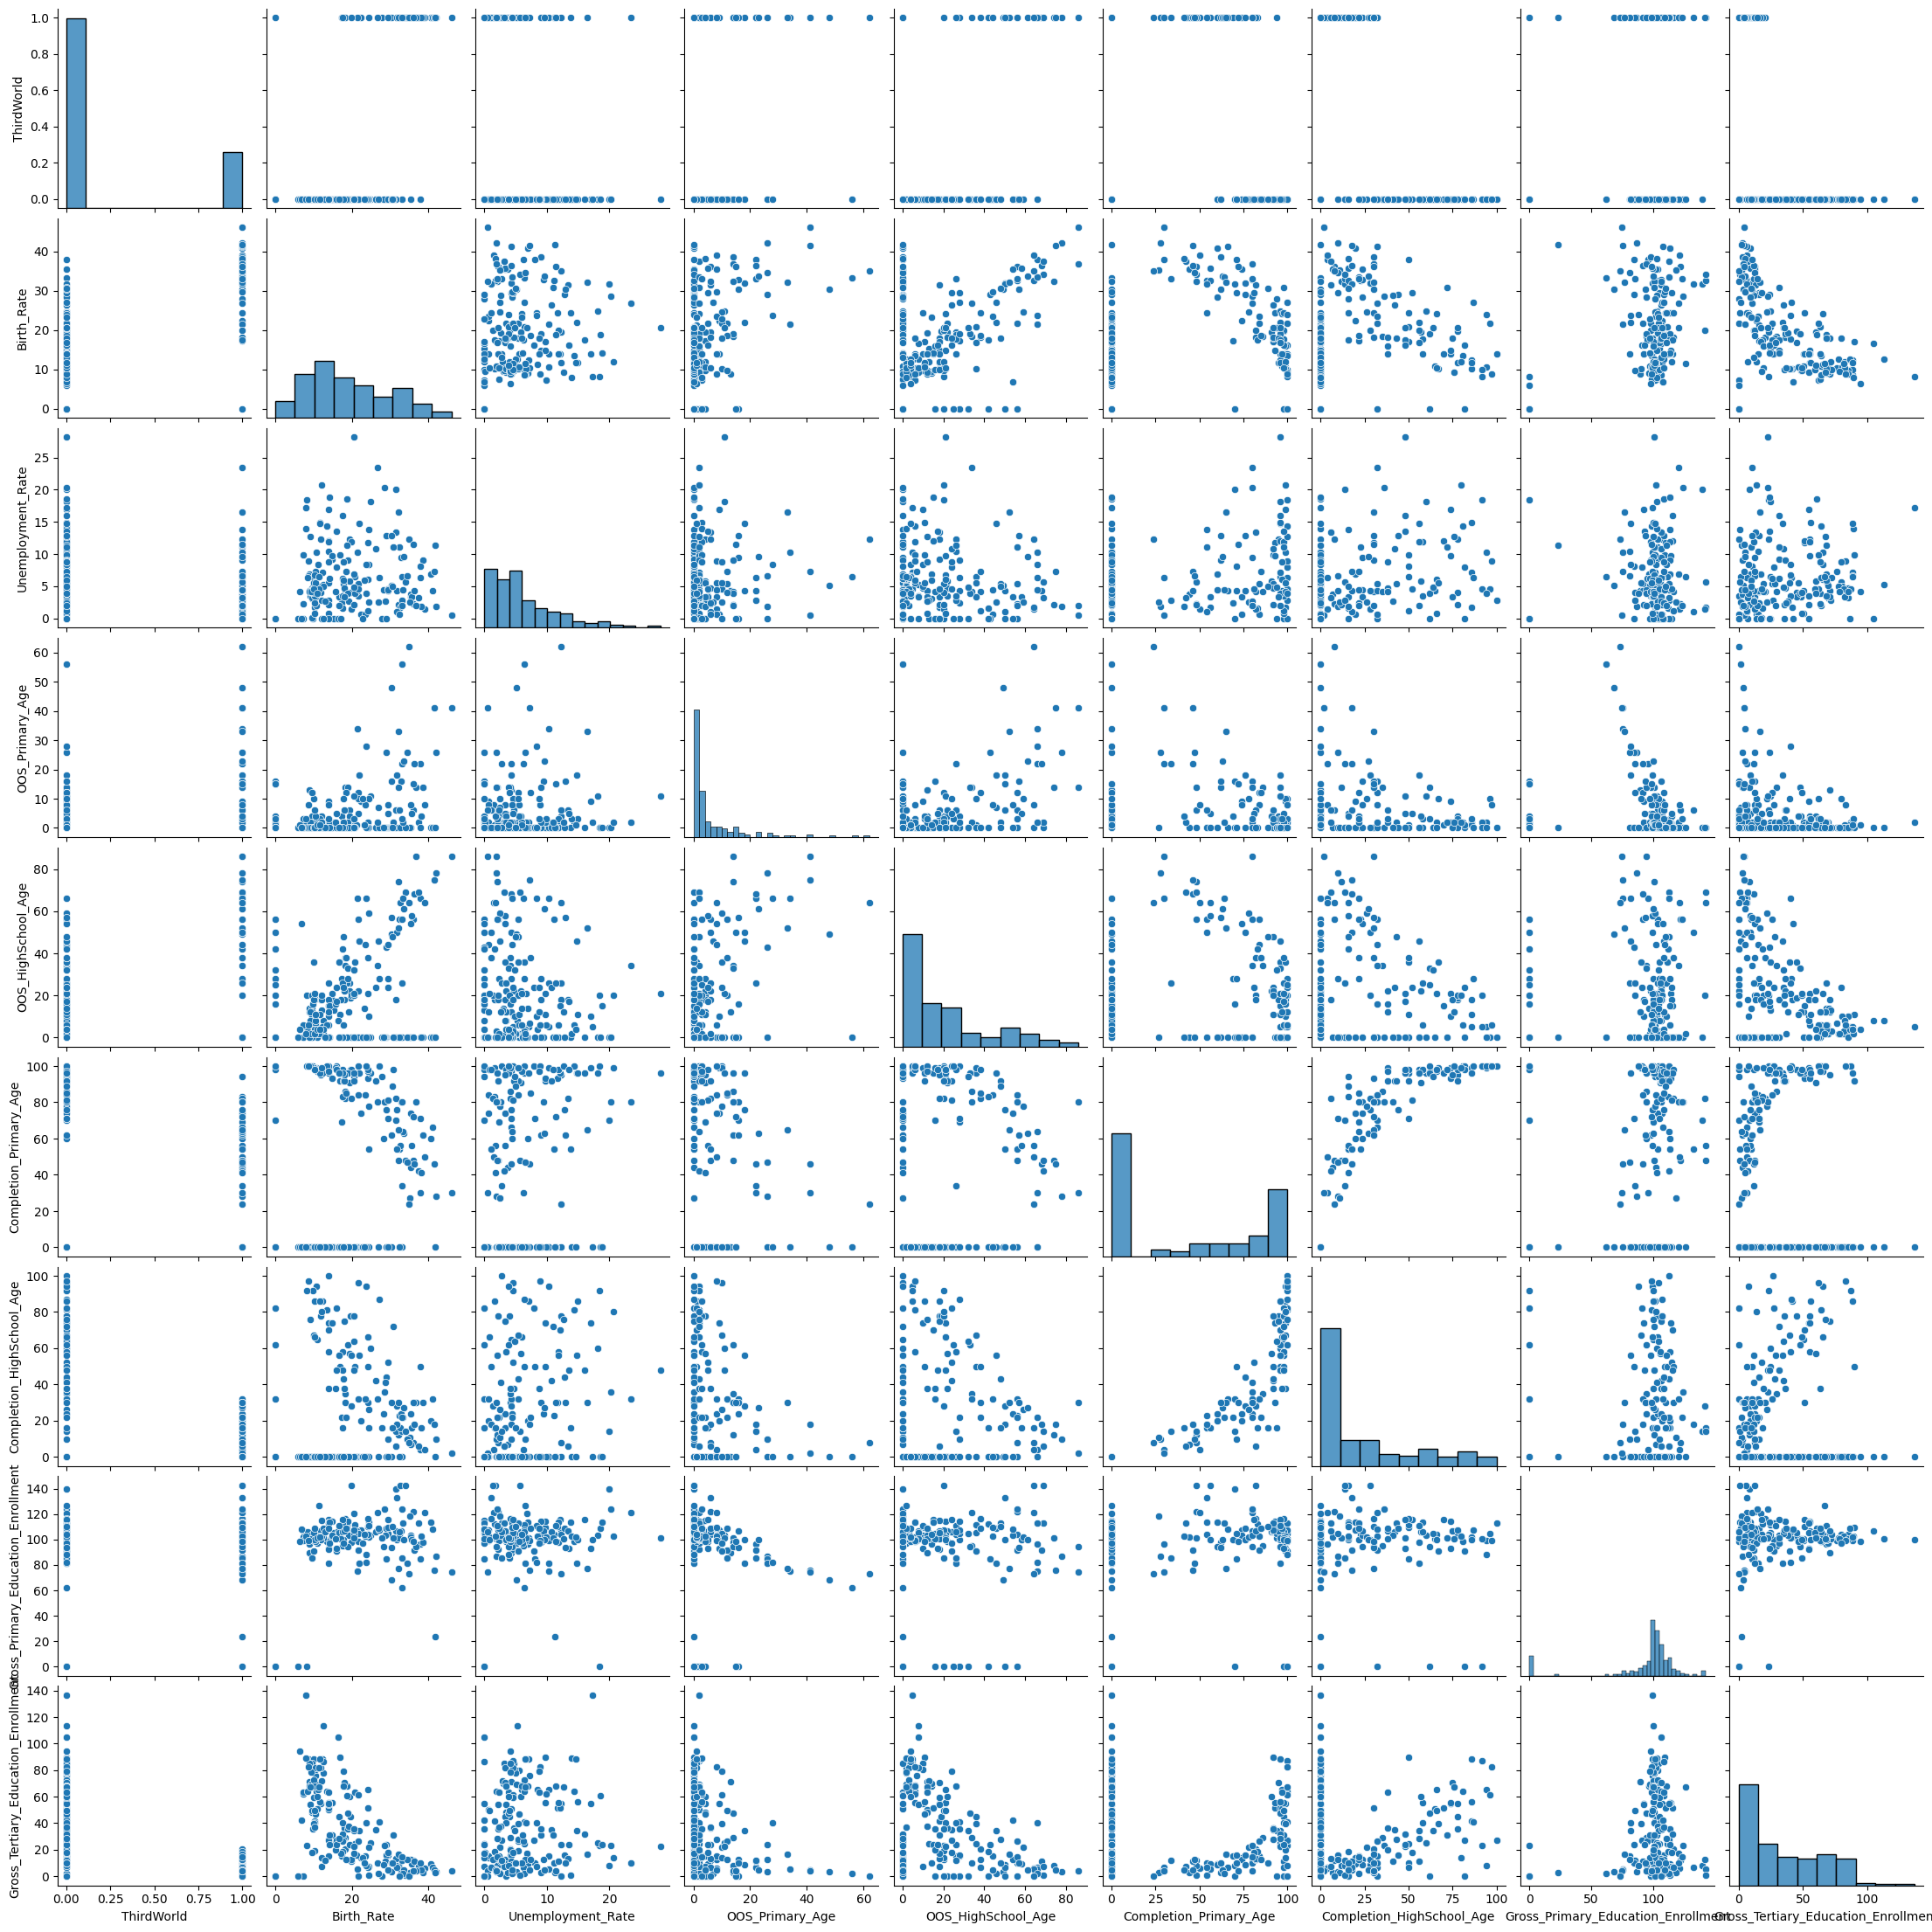

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
# Show scatterplot matrix for numerical columns from original dataframe, using hue as ThirdWorld

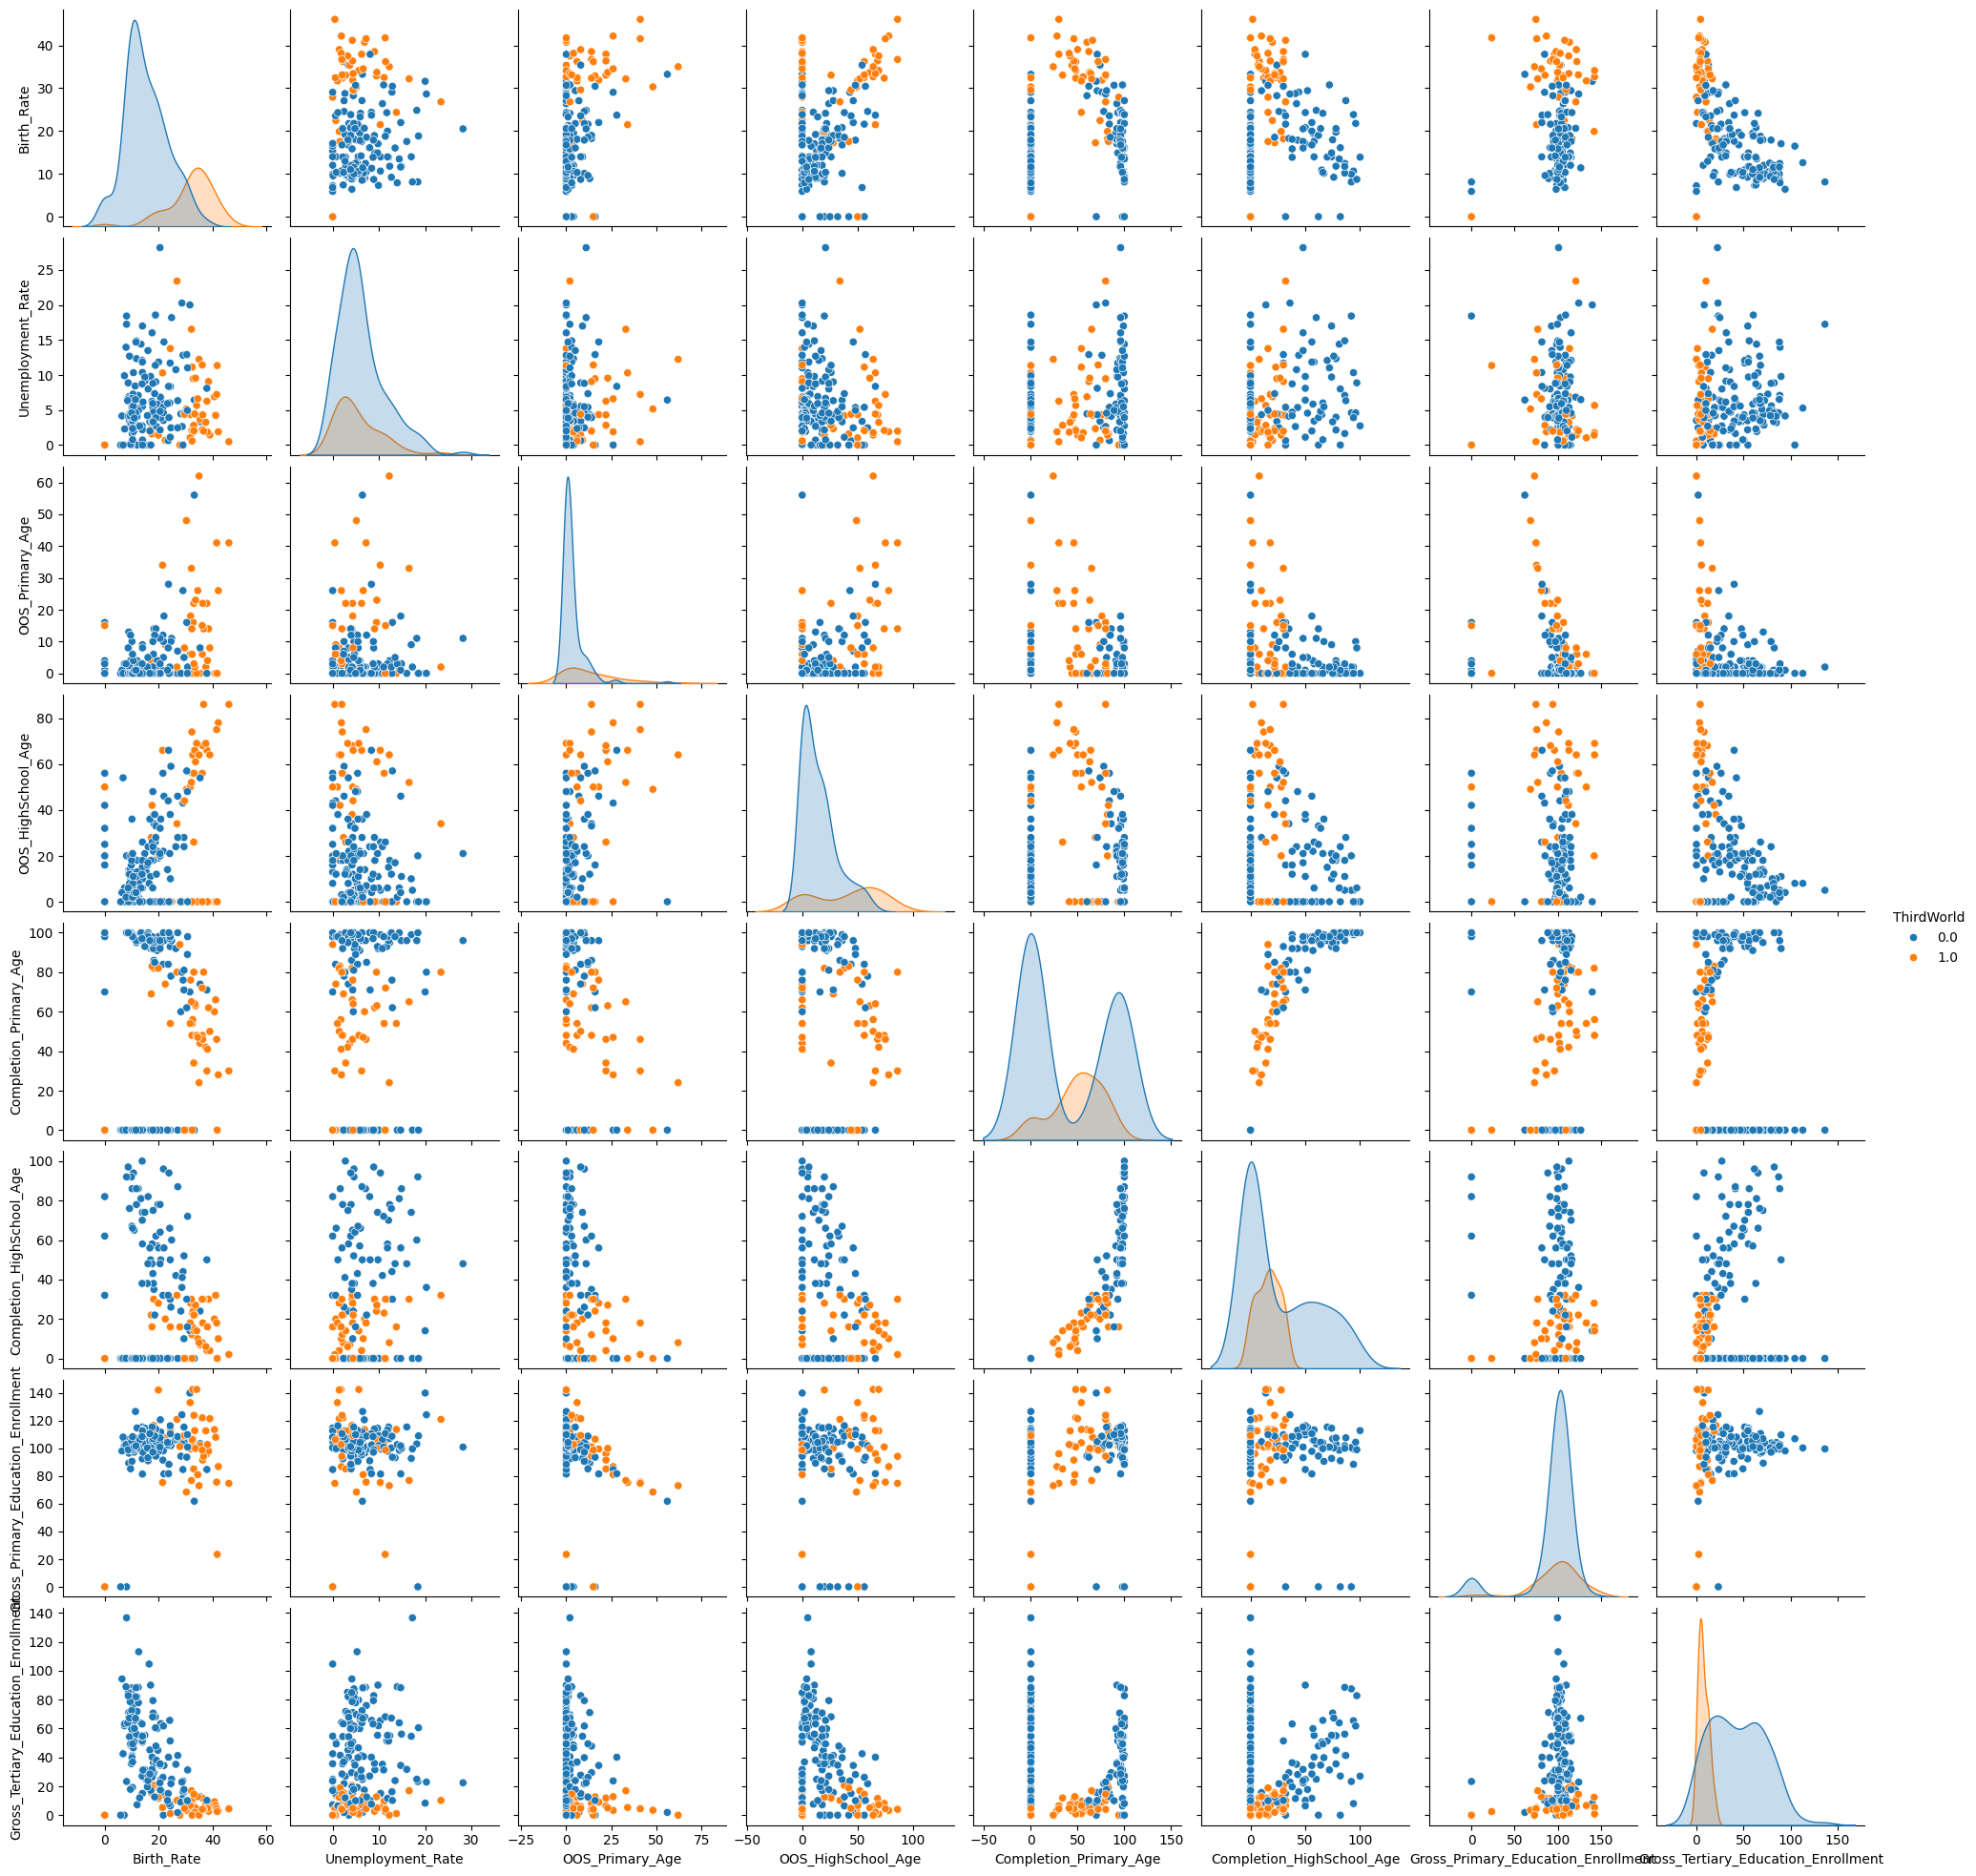

In [ ]:
sns.pairplot(df, hue='ThirdWorld')
plt.show()